In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import scipy.stats as stats
from scipy.integrate import solve_ivp

# python font no dingbattes
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]  # fallback list

/Users/apoorvasingh/Desktop/MZB-new-analysis/.venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
#Change the working directory
import os
os.chdir('/Users/apoorvasingh/Desktop/MZB-new-analysis')

In [3]:
#open the output file
file_path = 'data/New output (pkl)/Steady State/Unified_model/Feedback_T2_S.pkl'
with open(file_path, 'rb') as f:
    unified_df = pkl.load(f)
    
unified = unified_df.draws_pd()
    
file_path = 'data/New output (pkl)/Steady State/SHM/SHM_T2.pkl'
with open(file_path, 'rb') as f:
    SHM_df = pkl.load(f)
    
# file_path = 'data/New output (pkl)/Steady State/SHM/SHM_FO.pkl'
# with open(file_path, 'rb') as f:
#     data_neutral_FO = pkl.load(f)

/Users/apoorvasingh/Desktop/MZB-new-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# open experimental data file 
df_adult = pd.read_csv('data/New_data/new_data_MZB.csv')
df_adult = df_adult.sort_values(by='Age at S1K')
df_adult.loc[1, 'Age at BMT'] = 74
#Add one column in df_Ki67 and df_Nfd for grouping the data based on age at bmt
df_adult['agebin'] = pd.cut(df_adult['Age at BMT'], bins=[0,70, 140], labels=['<10 weeks', '>10 weeks'])


df_ont = pd.read_csv('data/Ontogeny_T1.csv')

In [5]:
def P(t):
    theta_0 = np.exp(14.10)
    nu = 0.25
    n = 1.8
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
 
def b(M, b_param, K):
    return b_param * (1 - (M / K))

def b_m(M, rho, M_stable, K):
    b_param = rho / (1 - (M_stable / K))
    return b_param * (1 - (M / K))
 
# Define the ODE function
# Initial conditions at time t=40
M0 = [12058]

In [6]:
def chi_source(time, chi_est=0.83, nu=0.08, t0=10):
    if (time - t0) < 0:
        return 0.0
    else:
        return chi_est * (1 - np.exp(-nu * (time - t0)))
    
def eps_donor(time, m=-1.9e-4, c=0.97, t0=40):
    if (time - t0) < 0:
        return 0.0
    else:
        return m * (time - t0) + c
    
def eps_host(time, m=-3.8e-5, c=0.88, t0=40):
    if (time - t0) < 0:
         return 0.0
    else:
        return m * (time - t0) + c
    
def b(M, rho, M_stable, K):
    b_param = rho / (1 - (M_stable / K))
    return b_param * (1 - (M / K))

In [7]:
# solve exponential ode using posterior samples
y_pred_samples = []

time_points_counts = np.linspace(11, 750, 750)
model_params = (unified['rho'], unified['delta'], unified['K'], unified['M_stable'])

for i in range(len(unified['rho'])):
    rho = unified['rho'][i]
    delta = unified['delta'][i]
    k = unified['K'][i]
    M_stable = unified['M_stable'][i]
    
    def model_ode(t, M, rho, delta, M_stable, K):
        Lambda = delta - rho
        dMdt = Lambda * M_stable + b_m(M, rho, M_stable, K) * M - delta * M
        return np.array(dMdt)
    y0_val = [12058]
    y_pred = solve_ivp(model_ode, [11, 750], y0_val, t_eval=time_points_counts, args=(rho, delta, M_stable, k))
    y_pred_samples.append(y_pred.y.flatten())



In [8]:
def rho_dd(M, rho, K, M_stable):
    """Density-dependent division rate"""
    b_param = rho / (1 - (M_stable / K))
    return b_param * (1 - (M / K))

def ode_sys_unified(time, X, rho, delta, M_stable,k, ageATBMT):
    """
    ODE system for unified model
    
    Parameters:
    -----------
    time : float
        Current time point
    X : array-like
        State vector [donor Ki67+, donor Ki67-, host Ki67+, host Ki67-]
    parms : array-like
        Parameters [rho, delta, K, M_stable, ageATBMT]
    
    Returns:
    --------
    dXdt : numpy array
        Derivatives of state variables
    """
    
    # Fixed parameters
    beta = 3.5
    
    # Calculated parameters
    lamda = delta - rho  # net loss rate
    S = lamda * M_stable # influx rate at time ts
    
    # Total cell count
    M_total = X[0] + X[1] + X[2] + X[3]
    
    # Calculate density-dependent division rate
    rho_dens = rho_dd(M_total, rho, k, M_stable)
    
    # Initialize derivatives
    dXdt = np.zeros(4)
    
    # Donor Ki67+ cells
    dXdt[0] = (S * eps_donor(time) * chi_source(time - ageATBMT) + 
               rho_dens * (X[0] + 2 * X[1]) - ((1 / beta) + delta) * X[0])
    
    # Donor Ki67- cells
    dXdt[1] = (S * (1 - eps_donor(time)) * chi_source(time - ageATBMT) + 
               (1 / beta) * X[0] - (rho_dens + delta) * X[1])
    
    # Host Ki67+ cells
    dXdt[2] = (S * eps_host(time) * (1 - chi_source(time - ageATBMT)) + 
               rho_dens * (X[2] + 2 * X[3]) - ((1 / beta) + delta) * X[2])
    
    # Host Ki67- cells
    dXdt[3] = (S * (1 - eps_host(time)) * (1 - chi_source(time - ageATBMT)) + 
               (1 / beta) * X[2] - (rho_dens + delta) * X[3])
    
    return dXdt

In [9]:
# estimated parameters 
rho = unified_df.stan_variable('rho') # division rate
delta = unified_df.stan_variable('delta') # death rate
M_stable = unified_df.stan_variable('M_stable') # stable cell count
k = unified_df.stan_variable('K') # carrying capacity
kappa0 = unified_df.stan_variable('kappa_0')


In [10]:
# write a function to solve the ODEs and return the results as a df
def solve_ode_system(rho, delta, M_stable, k, kappa0, age_at_bmt, solve_time_start, oupt):
    """Solve the ODE system for given parameters and return results as a DataFrame."""

    y0 = solve_ivp(model_ode, [11, 40], M0, t_eval=[40], args=(rho, delta, k, M_stable))
    host_ki67_plus = np.mean(kappa0*y0.y[:, -1])
    host_ki67_minus = np.mean((1-kappa0)*y0.y[:, -1])
    # Initial conditions at t=40
    initial_cond_t40 = np.array([0, 0, host_ki67_plus, host_ki67_minus])  # [donor_ki67+, donor_ki67-, host_ki67+, host_ki67-]

    # Use mean values for rho and delta for ODE solving
    rho_mean = np.mean(rho)
    delta_mean = np.mean(delta)
    M_stable_mean = np.mean(M_stable)
    k_mean = np.mean(k)
    
    ic_solution = solve_ivp(
        ode_sys_unified, (40, age_at_bmt), initial_cond_t40, args=(rho_mean, delta_mean, M_stable_mean, k_mean, age_at_bmt)
    )
    initial_at_bmt = ic_solution.y[:, -1]

    # t_span = (age_at_bmt, 750)
    t_eval = np.arange(solve_time_start, 750, 1)
    
    # Solve the ODEs
    sol = solve_ivp(ode_sys_unified, t_span=[11,750], y0=initial_at_bmt, args=(rho, delta, M_stable, k, age_at_bmt), t_eval=t_eval, method='RK45')

    # calculate chimerism in the source
    chi_values = np.array([chi_source(t - age_at_bmt) for t in sol.t])
    
    # Create a DataFrame from the solution
    df_results = pd.DataFrame(sol.y.T, columns=['Donor_Ki67+', 'Donor_Ki67-', 'Host_Ki67+', 'Host_Ki67-'])
    # calculate total MZ cells and Nfd
    df_results['Total_MZ'] = df_results['Donor_Ki67+'] + df_results['Donor_Ki67-'] + df_results['Host_Ki67+'] + df_results['Host_Ki67-']
    df_results['chi_source'] = chi_values
    df_results['Nfd'] = (df_results['Donor_Ki67+'] + df_results['Donor_Ki67-']) / (df_results['Total_MZ'] * df_results['chi_source'])
    # calculate fractions of Ki67+ cells in donor and host
    df_results['Frac_Ki67+_Donor'] = df_results['Donor_Ki67+'] / (df_results['Donor_Ki67+'] + df_results['Donor_Ki67-']) 
    df_results['Frac_Ki67+_Host'] = df_results['Host_Ki67+'] / (df_results['Host_Ki67+'] + df_results['Host_Ki67-']) 

    if oupt == 'counts':
        return df_results[['Total_MZ']]
    elif oupt == 'Nfd':
        return df_results[['Nfd']]
    elif oupt == 'ki67':
        return df_results[['Frac_Ki67+_Donor', 'Frac_Ki67+_Host']]



def get_ode_summary(rho, delta, M_stable, k, kappa0, age_at_bmt, solve_time_start, n_samples, oupt):
    """
    Solve the ODE system for n_samples parameter sets and return summary statistics as a DataFrame.
    """
    host_age = np.arange(solve_time_start, 750, 1)
    n_time = host_age.size

    if oupt == 'ki67':
        donor_samples = np.empty((n_time, n_samples), dtype=float)
        host_samples = np.empty((n_time, n_samples), dtype=float)

        for i in range(n_samples):
            df_sol = solve_ode_system(
                rho[i], delta[i], M_stable[i], k[i], kappa0[i],
                age_at_bmt=age_at_bmt,
                solve_time_start=solve_time_start,
                oupt=oupt
            )
            donor_samples[:, i] = df_sol['Frac_Ki67+_Donor'].to_numpy()
            host_samples[:, i] = df_sol['Frac_Ki67+_Host'].to_numpy()

        df_summary_donor = pd.DataFrame({
            'mean_pred': np.median(donor_samples, axis=1),
            'lb': np.quantile(donor_samples, 0.025, axis=1),
            'ub': np.quantile(donor_samples, 0.975, axis=1),
            'Host_Age': host_age,
            'Type': 'Donor'
        })
        df_summary_host = pd.DataFrame({
            'mean_pred': np.median(host_samples, axis=1),
            'lb': np.quantile(host_samples, 0.025, axis=1),
            'ub': np.quantile(host_samples, 0.975, axis=1),
            'Host_Age': host_age,
            'Type': 'Host'
        })
        df_summary = pd.concat([df_summary_donor, df_summary_host], axis=0)

    else:
        if oupt == 'counts':
            value_col = 'Total_MZ'
        elif oupt == 'Nfd':
            value_col = 'Nfd'
        else:
            raise ValueError(f"Unsupported output type: {oupt}")

        output_samples = np.empty((n_time, n_samples), dtype=float)
        for i in range(n_samples):
            df_sol = solve_ode_system(
                rho[i], delta[i], M_stable[i], k[i], kappa0[i],
                age_at_bmt=age_at_bmt,
                solve_time_start=solve_time_start,
                oupt=oupt
            )
            output_samples[:, i] = df_sol[value_col].to_numpy()

        df_summary = pd.DataFrame({
            'mean_pred': np.median(output_samples, axis=1),
            'lb': np.quantile(output_samples, 0.025, axis=1),
            'ub': np.quantile(output_samples, 0.975, axis=1),
            'Host_Age': host_age
        })

    return df_summary

In [11]:
bmt_ages = np.array([41, 42, 51, 58, 65, 74, 87, 89, 101])
solve_times = np.array([59, 124, 141, 212, 158, 88, 731, 306, 291])

In [ ]:
# For Ki67 donor and host
df_donor_allbmt = pd.DataFrame()
df_host_allbmt = pd.DataFrame()

for i in range(len(bmt_ages)):
    age_at_bmt = bmt_ages[i]
    solve_time_start = solve_times[i]
    df_summary = get_ode_summary(rho, delta, M_stable, k, kappa0, age_at_bmt=age_at_bmt, solve_time_start=solve_time_start, n_samples=2000, oupt='ki67') 
    df_summary['agebin'] = i
    df_donor_allbmt = pd.concat([df_donor_allbmt, df_summary[df_summary['Type'] == 'Donor']], axis=0)
    df_host_allbmt = pd.concat([df_host_allbmt, df_summary[df_summary['Type'] == 'Host']], axis=0)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


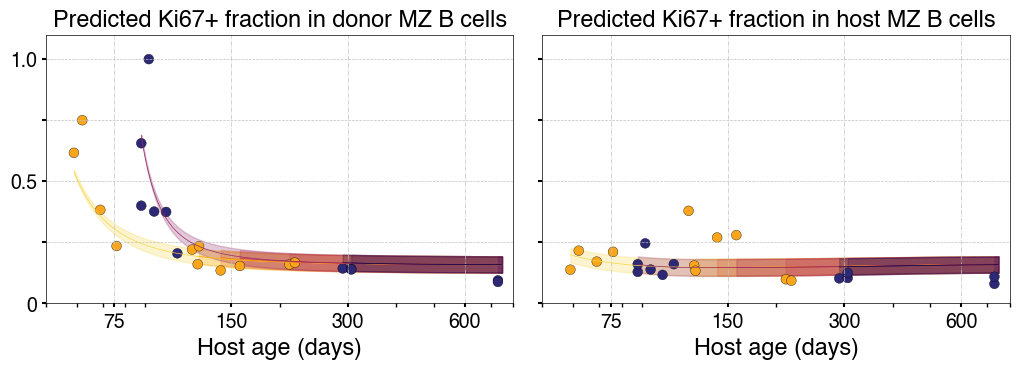

In [ ]:
# global font size
sns.set_context("notebook", font_scale=1.4)

# plot ki67 donor and host as subplots
my_pal = ['#FAA51A','#2e2976']

col_pal = sns.color_palette("inferno", n_colors=len(df_donor_allbmt['agebin'].unique()))
col_pal = col_pal[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4), sharey=True)
sns.lineplot(data=df_donor_allbmt, x='Host_Age', y='mean_pred', hue='agebin', palette=col_pal, legend='full', ax=ax1, linewidth=0.5)    
sns.lineplot(data=df_host_allbmt, x='Host_Age', y='mean_pred', hue='agebin', palette=col_pal, legend=False, ax=ax2, linewidth=0.5)  
# Fill between for each agebin
for agebin, color in zip(df_donor_allbmt['agebin'].unique(), col_pal):
    df_bin = df_donor_allbmt[df_donor_allbmt['agebin'] == agebin]
    ax1.fill_between(df_bin['Host_Age'], df_bin['lb'], df_bin['ub'], color=color, alpha=0.25, label=f'BMT Age bin {agebin}')
    df_bin2 = df_host_allbmt[df_host_allbmt['agebin'] == agebin]
    ax2.fill_between(df_bin2['Host_Age'], df_bin2['lb'], df_bin2['ub'], color=color, alpha=0.25)
sns.scatterplot(data=df_adult, x='Age at S1K', y='frac_Ki67+_MZ_donor', hue='agebin', palette=my_pal, s=50, ax=ax1, edgecolor='black', linewidth=0.25, legend=False)
sns.scatterplot(data=df_adult, x='Age at S1K', y='frac_Ki67+_MZ_host', hue='agebin', palette=my_pal, s=50, ax=ax2, edgecolor='black', linewidth=0.25, legend=False)
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_title('Predicted Ki67+ fraction in donor MZ B cells')
ax1.legend_.remove()
ax1.set_xscale('log')
ax1.set_xlim(50, 800)
ax1.set_ylim(0, 1.1)
ax1.set_xticks([75, 150, 300, 600], [75, 150, 300, 600])
ax1.set_yticks(np.arange(0, 1.25, 0.25))
ax1.set_yticklabels([0,'' ,0.5,'',  1.0])

# Axis border width
for spine in ax1.spines.values():
    spine.set_linewidth(0.5)   # try 0.6 / 0.8 / 1.0

# Tick mark width
ax1.tick_params(axis='both', which='both', width=0.8)
ax1.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
ax1.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
ax1.set_xlabel('Host age (days)')
ax1.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
ax1.tick_params(axis="both", which="major", length=3, width=1.5)
ax1.tick_params(axis="both", which="minor", length=3, width=1)

ax2.set_ylabel('')
ax2.set_title('Predicted Ki67+ fraction in host MZ B cells')
ax2.set_xscale('log')
ax2.set_xlim(50, 800)
ax2.set_ylim(0, 1.1)
ax2.set_xticks([75, 150, 300, 600], [75, 150, 300, 600])
ax2.set_yticks(np.arange(0, 1.25, 0.25))

# # Exact 9 age values for colorbar labels
# agebins = np.sort(df_donor_allbmt['agebin'].unique()).astype(int) 
# age_labels = np.array([int(bmt_ages[i]) for i in agebins])     


# norm = plt.Normalize(vmin=age_labels.min()/7, vmax=age_labels.max()/7)
# sm = plt.cm.ScalarMappable(cmap='inferno_r', norm=norm)
# sm.set_array([])
# ax2 = plt.gca()
# cbar = plt.colorbar(sm, ax=ax2, fraction=0.03, pad=0.02, alpha=0.8)
# cbar.set_label('Age at BMT (weeks)')

# Axis border width
for spine in ax2.spines.values():
    spine.set_linewidth(0.5)   # try 0.6 / 0.8 / 1.0

# Tick mark width
ax2.tick_params(axis='both', which='both', width=0.8)
ax2.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
ax2.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
ax2.set_xlabel('Host age (days)')
ax2.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
ax2.tick_params(axis="both", which="major", length=3, width=1.5)
ax2.tick_params(axis="both", which="minor", length=3, width=1)

plt.tight_layout()

# save both figures
fig.savefig('Fig4D.pdf', dpi=300)

In [ ]:
df_allbmt = pd.DataFrame()

for i in range(len(bmt_ages)):
    age_at_bmt = bmt_ages[i]
    solve_time_start = solve_times[i]
    df_summary = get_ode_summary(rho, delta, M_stable, k, kappa0, age_at_bmt=age_at_bmt, solve_time_start=solve_time_start, n_samples=2000, oupt='Nfd')
    df_summary['agebin'] = i
    df_allbmt = pd.concat([df_allbmt, df_summary], axis=0)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


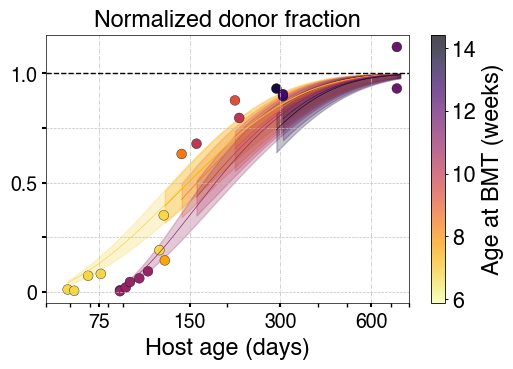

In [ ]:
# plot NFd


fig, ax = plt.subplots(figsize=(5.5, 4))
sns.lineplot(data=df_allbmt, x='Host_Age', y='mean_pred', hue='agebin', palette=col_pal, legend='full', ax=ax, linewidth=0.5)
# Fill between for each agebin
for agebin, color in zip(df_allbmt['agebin'].unique(), col_pal):
	df_bin = df_allbmt[df_allbmt['agebin'] == agebin]
	ax.fill_between(df_bin['Host_Age'], df_bin['lb'], df_bin['ub'], color=color, alpha=0.25, label=f'BMT Age bin {agebin}')
sns.scatterplot(data=df_adult, x='Age at S1K', y='Nfd_MZ', hue='Age at BMT', palette=col_pal, s=50, edgecolor='black', linewidth=0.25, legend=False, ax=ax)
ax.set_xlabel('Host Age (days)')
ax.set_ylabel('Normalized Donor Fraction (Nfd)')
ax.set_title('Predicted Nfd over Host Age for Different BMT Ages')
ax.set_xlim(50, 800)
ax.set_xscale('log')
ax.set_xticks([75, 150,  300,  600])
ax.set_xticklabels([75, 150,  300,  600])
ax.set_ylabel('')
ax.set_yticks(np.arange(0, 1.25, 0.25))
ax.set_yticklabels([0,'' ,0.5,'',  1.0])
ax.set_xlabel('Host age (days)')
ax.set_title('Normalized donor fraction')
ax.axhline(y=1, color='black', linestyle='dashed', linewidth=1)

# Exact 9 age values for colorbar labels
agebins = np.sort(df_donor_allbmt['agebin'].unique()).astype(int) 
age_labels = np.array([int(bmt_ages[i]) for i in agebins])     


norm = plt.Normalize(vmin=age_labels.min()/7, vmax=age_labels.max()/7)
sm = plt.cm.ScalarMappable(cmap='inferno_r', norm=norm)
sm.set_array([])
ax2 = plt.gca()
cbar = plt.colorbar(sm, ax=ax, alpha=0.7)
cbar.set_label('Age at BMT (weeks)')
cbar.ax.tick_params(length=2, width=0.7)
# optional: fewer ticks
cbar.set_ticks([6, 8, 10, 12, 14]) 

# optional: thinner border
cbar.outline.set_linewidth(0.6)

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.5)   # try 0.6 / 0.8 / 1.0

# Tick mark width
ax.tick_params(axis='both', which='both', width=1)
ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
# tick label font size
ax.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1.5)
ax.tick_params(axis="both", which="minor", length=3, width=1)
# no legend 
ax.legend([],[], frameon=False)
plt.tight_layout()


# save the figure
plt.savefig('Fig4C.pdf', dpi=300)

In [ ]:
df_counts = pd.DataFrame()

for i in range(len(bmt_ages)):
    age_at_bmt = bmt_ages[i]
    solve_time_start = solve_times[i]
    df_summary = get_ode_summary(rho, delta, M_stable, k, kappa0, age_at_bmt=age_at_bmt, solve_time_start=solve_time_start, n_samples=2000, oupt='counts')
    df_summary['agebin'] = i
    df_counts = pd.concat([df_counts, df_summary], axis=0)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


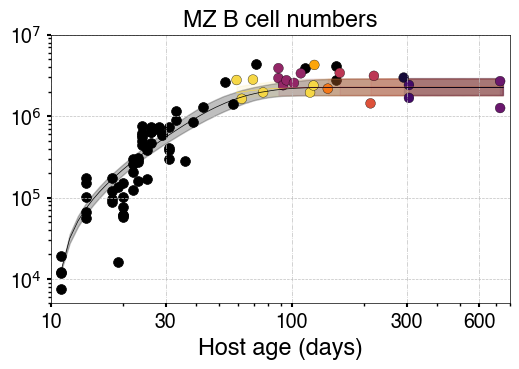

In [ ]:
col_pal = sns.color_palette("inferno", n_colors=len(df_counts['agebin'].unique()))
col_pal = col_pal[::-1]
# plot counts
ts1= np.arange(59, 750, 1)
ts2= np.arange(88, 750, 1)

fig, ax = plt.subplots(figsize=(5.5, 4))
sns.lineplot(data=df_counts, x='Host_Age', y='mean_pred', hue='agebin', palette=col_pal, legend='full', ax=ax, linewidth=0.5)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='total_MZ', s=50, color='black', edgecolor='black', linewidth=0.5, label='Young WT mice', legend=False)
plt.plot(time_points_counts, np.median(y_pred_samples, axis=0), color='black', linewidth=0.5)
plt.fill_between(time_points_counts,
                 np.percentile(y_pred_samples, 2.5, axis=0),
                 np.percentile(y_pred_samples, 97.5, axis=0),
                 color='black', alpha=0.25)
# Fill between for each agebin
for agebin, color in zip(df_counts['agebin'].unique(), col_pal):
    df_bin = df_counts[df_counts['agebin'] == agebin]
    ax.fill_between(df_bin['Host_Age'], df_bin['lb'], df_bin['ub'], color=color, alpha=0.1, label=f'BMT Age bin {agebin}')
sns.scatterplot(data=df_adult, x='Age at S1K', y='total_MZ', hue='Age at BMT', palette=col_pal, s=50, edgecolor='black', linewidth=0.25, legend=False, ax=ax)
ax.set_xlabel('Host age (days)')
ax.set_title('MZ B cell numbers')
ax.set_ylabel('')
ax.set_xlim(10, 800)
ax.set_xscale('log')
ax.set_ylim(5*1e3, 1e7)
ax.set_xticks([10, 30, 100, 300, 600])
ax.set_xticklabels([10, 30, 100, 300, 600])
ax.set_yscale('log')
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
# y axis ticks as 10^4, 10^5, 10^6, 10^7
ax.set_yticks([1e4, 1e5, 1e6, 1e7])
ax.set_yticklabels(['10$^4$','10$^5$', '10$^6$', '10$^7$'])

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.5)   # try 0.6 / 0.8 / 1.0

# Tick mark width
ax.tick_params(axis='both', which='both', width=0.8)
ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
ax.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1.5)
ax.tick_params(axis="both", which="minor", length=2, width=1)
# no legend
plt.legend([],[], frameon=False)
plt.tight_layout()
# save the figure
plt.savefig('Fig4B.pdf', dpi=300)

(1000, 1) (2000,) (2000,) (2000,)
(1000, 2000)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


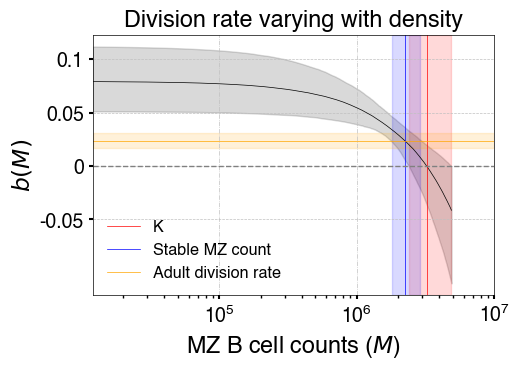

In [ ]:
def b(M, rho, M_stable, K):
    b_m = rho / (1 - (M_stable / K))
    return b_m * (1 - (M / K))

M = np.logspace(4.0812756, 6.6899, 1000)
# lamda = lamda_samples
# phi = (lamda_samples * M_stable_samples)/ 1308516
rho = unified_df.rho
M_stable = unified_df.M_stable
k = unified_df.K

# Reshape M to broadcast properly with posterior samples
M_broadcast = M[:, np.newaxis]  # Shape: (len(M), 1)
print(M_broadcast.shape, rho.shape, M_stable.shape, k.shape)
b_samples = b(M_broadcast, rho, M_stable, k)  # Shape: (len(M), n_samples)
print(b_samples.shape)


# Calculate statistics
b_median = np.median(b_samples, axis=1)  
b_lower = np.percentile(b_samples, 2.5, axis=1)
b_upper = np.percentile(b_samples, 97.5, axis=1)

# r_mean = np.mean(r_samples, axis=1)

fig, axes = plt.subplots(1, 1, figsize=(5.5, 4))
axes.plot(M, b_median, color='black', linewidth=0.5)
axes.fill_between(M, b_lower, b_upper, alpha=0.15, color='black')

plt.axvline(x=np.median(unified_df.K), color='red', label='K', linewidth=0.5)
plt.axvspan(np.quantile(unified_df.K, 0.025), np.quantile(unified_df.K, 0.975), color='red', alpha=0.15)

plt.axvline(x=np.median(M_stable), color='blue',  label='Stable MZ count', linewidth=0.5)
plt.axvspan(np.quantile(M_stable, 0.025), np.quantile(M_stable, 0.975), color='blue', alpha=0.15)

# plt.axhline(y=np.median(SHM_df.rho), color='black', linestyle='--', label='Adult division rate (SHM)')
# plt.axhspan(np.quantile(SHM_df.rho, 0.025), np.quantile(SHM_df.rho, 0.975), color='black', alpha=0.2)

plt.axhline(y=np.median(unified_df.rho), color='orange',  label='Adult division rate', linewidth=0.5)
plt.axhspan(np.quantile(unified_df.rho, 0.025), np.quantile(unified_df.rho, 0.975), color='orange', alpha=0.15)

plt.axhline(y=0, color='grey', linestyle='--', linewidth=1)
axes.set_xlim(12058, 1e7)
axes.set_xticks([1e5, 1e6, 1e7])
axes.set_xticklabels([ '10^5', '10^6', '10^7'])
axes.set_yticks([- 0.05, 0, 0.05, 0.1])
axes.set_yticklabels(['-0.05', '0', '0.05', '0.1'])
axes.set_xscale('log')
axes.set_ylabel(r'$b(M)$')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.5)   # try 0.6 / 0.8 / 1.0
plt.title('Division rate varying with density')
axes.set_xlabel(r'MZ B cell counts ($\mathit{M}$)')
axes.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
axes.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
axes.legend(fontsize='x-small', frameon=False)
ax.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1.5)
ax.tick_params(axis="both", which="minor", length=2, width=1)
plt.tight_layout()

#save figure
plt.savefig('figures/Fig5B.pdf', dpi=300)
plt.show()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


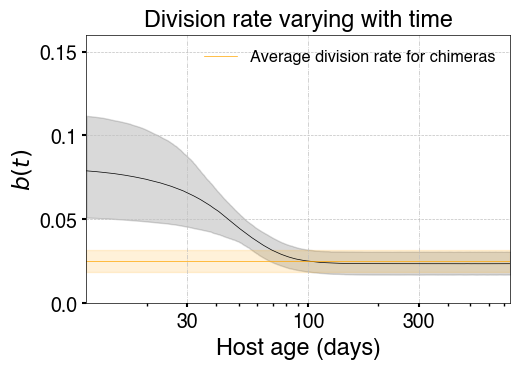

In [ ]:
# Define the birth rate function in terms of t (avoid name clash with variable 'r')
def b_time(rho, M, M_stable, K):
    """Instantaneous logistic birth rate b(M) given parameters."""
    b = rho / (1.0 - (M_stable / K))
    return b * (1.0 - (M / K))

def P(t):
    theta_0 = 14.08
    nu = 0.25
    n = 1.8
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
   

# Define the ODE function with signature (t, y, *args) required by solve_ivp
def ode_function(t, y, phi, rho, delta, M_stable, K):
    M_val = y[0]
    # dMdt = phi * P(t) + b_time(rho, M_val, M_stable, K) * M_val - delta*M_val
    dMdt = phi + b_time(rho, M_val, M_stable, K) * M_val - delta*M_val
    
    return [dMdt]

# Use posterior means (or derive S from posterior samples)
phi = (unified_df.delta - unified_df.rho) * unified_df.M_stable
rho = unified_df.rho
delta = unified_df.delta
M_stable = unified_df.M_stable
K = unified_df.K

# Compute S using posterior samples to get a representative mean source if desired
# This avoids mixing scalar means incorrectly.
# S = lamda * data_neutral.M_stable

M0 = [12058.0]
# use a reasonable time step (very small dt can make solver struggle); 0.1 matches other cells
t_ev = np.arange(11.0, 750.0, 0.1)
sol = np.zeros((len(rho), len(t_ev)))
for i in range(len(rho)):
    # Solve once over the full interval (vectorized call) instead of calling solve_ivp in a loop
    result = solve_ivp(ode_function,
                        [t_ev[0], t_ev[-1]],
                M0,
                t_eval=t_ev,
                args=(phi[i], rho[i], delta[i], M_stable[i], K[i]))
    sol[i, :] = result.y[0]

# Extract solution and compute r(t)
b_t = np.zeros((len(t_ev), len(rho)))
for i in range(len(rho)):
    M_t = sol[i, :]
    b_t[:, i] = b_time(rho[i], M_t, M_stable[i], K[i])

# Calculate statistics
b_median = np.median(b_t, axis=1)
b_lower = np.percentile(b_t, 2.5, axis=1)
b_upper = np.percentile(b_t, 97.5, axis=1)

fig, axes = plt.subplots(1, 1, figsize=(5.5, 4))
axes.plot(t_ev, b_median, color='black', linewidth=0.5)
axes.fill_between(t_ev, b_lower, b_upper, alpha=0.15, color='black')
# plt.axhline(y=0, color='grey', linestyle='--')
# plt.axhline(y=-np.mean(data_DDM.stan_variable('lambda'), axis=0), color='orange', linestyle='--', label='Growth Rate')
# plt.yscale('log')
plt.axhline(y=np.median(SHM_df.rho), color='orange', label='Average division rate for chimeras', linewidth=0.5)
plt.axhspan(np.quantile(SHM_df.rho, 0.025), np.quantile(SHM_df.rho, 0.975), color='orange', alpha=0.15)
# plt.axhline(y=np.median(posterior_df.rho), color='orange', linestyle='--', label='Adult division rate (Ontogeny)')
# plt.axhspan(np.quantile(posterior_df.rho, 0.025), np.quantile(posterior_df.rho, 0.975), color='orange', alpha=0.2)
axes.set_ylim(0, 0.16)
plt.yticks([0.0, 0.05, 0.1, 0.15], [0.0, 0.05, 0.1, 0.15])
axes.set_xlim(11, 740)
plt.xscale('log')
plt.xticks([ 30, 100, 300], [ 30, 100, 300])
axes.set_ylabel('')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.5)   # try 0.6 / 0.8 / 1.0

# Tick mark width
# ax.tick_params(axis='both', which='both', width=0.8)
plt.title('Division rate varying with time')
axes.set_ylabel(r'$b(t)$')
axes.set_xlabel('Host age (days)')
ax.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1.5)
ax.tick_params(axis="both", which="minor", length=2, width=1)
axes.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
axes.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
plt.tight_layout()
axes.legend(fontsize='x-small', frameon=False)
#save figure
plt.savefig('figures/Fig5C.pdf', dpi=300)
plt.show()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


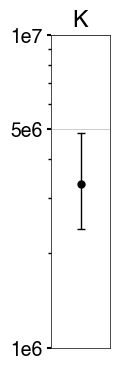

In [ ]:
#Plot K

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=3, markersize=5, elinewidth=1)
    
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))
plot_with_error_bars(K, '' ,'black', ax)
# ax.set_ylim(100, 550)
# ax.set_yticks([100, 200, 300, 400, 500])
# ax.set_yticklabels(['100', '', '300', '', '500'], fontsize=10)
ax.set_ylim(1e6, 1e7)
ax.set_yscale('log')
ax.set_yticks([1e6, 5e6, 1e7])
ax.set_yticklabels(['1e6', '5e6', '1e7'], fontsize=14)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('K')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.5) 
ax.tick_params(axis="both", which="major", length=3, width=1.5)
ax.tick_params(axis="both", which="minor", length=2, width=1)
# ax.set_xlabel('Turnover \n Time', fontsize=10)


ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.9)
plt.tight_layout()
plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Ontogeny_K_parameter.pdf', dpi=300)
plt.show()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


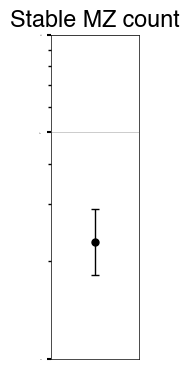

In [ ]:
#Plot mz stable

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=3, markersize=5, elinewidth=1)
    
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))
plot_with_error_bars(M_stable, '' ,'black', ax)
# ax.set_ylim(100, 550)
# ax.set_yticks([100, 200, 300, 400, 500])
# ax.set_yticklabels(['100', '', '300', '', '500'], fontsize=10)
ax.set_ylim(1e6, 1e7)
ax.set_yscale('log')
ax.set_yticks([1e6, 5e6, 1e7])
ax.set_yticklabels(['1e6', '5e6', '1e7'], fontsize=1)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('Stable MZ count')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.5) 
ax.tick_params(axis="both", which="major", length=3, width=1.5)
ax.tick_params(axis="both", which="minor", length=2, width=1)
# ax.set_xlabel('Turnover \n Time', fontsize=10)


ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.9)
plt.tight_layout()
plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Ontogeny_M_stable_parameter.pdf', dpi=300)
plt.show()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


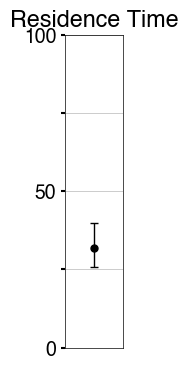

In [ ]:
# Residence time 

residence_time = 1 / unified_df.delta

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=3, markersize=5, elinewidth=1)
    
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))
plot_with_error_bars(residence_time, '' ,'black', ax)
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_yticklabels(['0', '', '50', '', '100'], fontsize=14)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('Residence Time')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.5) 
ax.tick_params(axis="both", which="major", length=3, width=1.5)
ax.tick_params(axis="both", which="minor", length=2, width=1)
# ax.set_xlabel('Turnover \n Time', fontsize=10)


ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.9)
plt.tight_layout()
plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Ontogeny_Residence_Time_parameter.pdf', dpi=300)
plt.show()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


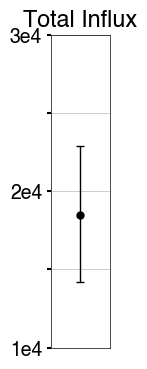

In [ ]:
#Plot total influx
lambda_unified = unified_df.stan_variable("delta") - unified_df.stan_variable("rho")
total_influx_unified = lambda_unified * unified_df.stan_variable("M_stable")

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=3, markersize=5, elinewidth=1)
    
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))
plot_with_error_bars(total_influx_unified, '' ,'black', ax)
ax.set_ylim(10000, 30000)
# ax.set_yticks([100, 200, 300, 400, 500])
# ax.set_yticklabels(['100', '', '300', '', '500'], fontsize=10)
# ax.set_ylim(1e6, 1e7)
# ax.set_yscale('log')
ax.set_yticks([10000, 15000, 20000, 25000, 30000])
ax.set_yticklabels(['1e4', '', '2e4', '', '3e4'], fontsize=14)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('Total Influx')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.5) 
ax.tick_params(axis="both", which="major", length=3, width=1.5)
ax.tick_params(axis="both", which="minor", length=2, width=1)
# ax.set_xlabel('Turnover \n Time', fontsize=10)


ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.9)
plt.tight_layout()
plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Ontogeny_Total_Influx.pdf', dpi=300)
plt.show()

[[-15.78687865 -20.42334033 -39.08081656 ... -13.50737024 -17.07106288
  -13.577946  ]
 [-15.80252123 -20.44800505 -39.13638216 ... -13.51984533 -17.08789832
  -13.59220104]
 [-15.81826328 -20.47281286 -39.19220414 ... -13.53240734 -17.10483517
  -13.60655863]
 ...
 [ 86.06965345  74.98613821  75.27762532 ...  90.12411042  86.95749325
   80.37405528]
 [ 86.06946204  74.98561632  75.27730144 ...  90.12300934  86.95676782
   80.37323762]
 [ 86.06926355  74.98507236  75.27696924 ...  90.12191559  86.95601144
   80.37242328]]


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


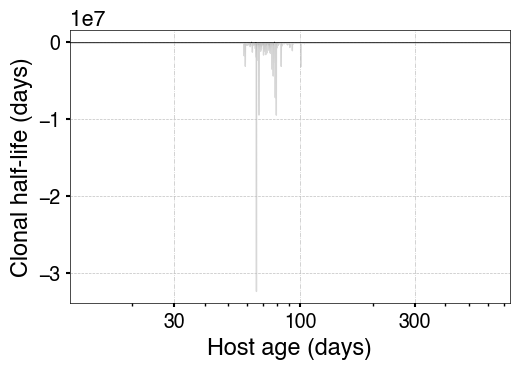

In [ ]:
#Plot clonal half life as a function of time 

# Define the birth rate function in terms of t (avoid name clash with variable 'r')
def b_time(rho, M, M_stable, K):
    """Instantaneous logistic birth rate b(M) given parameters."""
    b = rho / (1.0 - (M_stable / K))
    return b * (1.0 - (M / K))

# Define the ODE function with signature (t, y, *args) required by solve_ivp
def ode_function(t, y, phi, rho, delta, M_stable, K):
    M_val = y[0]
    # dMdt = phi * P(t) + b_time(rho, M_val, M_stable, K) * M_val - delta*M_val
    dMdt = phi + b_time(rho, M_val, M_stable, K) * M_val - delta*M_val
    
    return [dMdt]

# Use posterior means (or derive S from posterior samples)
phi = (unified_df.delta - unified_df.rho) * unified_df.M_stable
rho = unified_df.rho
delta = unified_df.delta
M_stable = unified_df.M_stable
K = unified_df.K

# Compute S using posterior samples to get a representative mean source if desired
# This avoids mixing scalar means incorrectly.
# S = lamda * data_neutral.M_stable

M0 = [12058.0]
# use a reasonable time step (very small dt can make solver struggle); 0.1 matches other cells
t_ev = np.arange(11.0, 750.0, 0.1)
sol = np.zeros((len(rho), len(t_ev)))
for i in range(len(rho)):
    # Solve once over the full interval (vectorized call) instead of calling solve_ivp in a loop
    result = solve_ivp(ode_function,
                        [t_ev[0], t_ev[-1]],
                M0,
                t_eval=t_ev,
                args=(phi[i], rho[i], delta[i], M_stable[i], K[i]))
    sol[i, :] = result.y[0]

# Extract solution and compute r(t)
b_t = np.zeros((len(t_ev), len(rho)))
for i in range(len(rho)):
    M_t = sol[i, :]
    b_t[:, i] = b_time(rho[i], M_t, M_stable[i], K[i])
    
# Calculate clonal half-life as ln(2)/delta - b(t)
clonal_half_life = np.zeros((len(t_ev), len(delta)))
for i in range(len(delta)):
    clonal_half_life[:, i] = np.log(2) / (delta[i] - b_t[:, i])
    
print(clonal_half_life)
# Calculate statistics
clonal_half_life_median = np.mean(clonal_half_life, axis=1)
clonal_half_life_lower = np.percentile(clonal_half_life, 0.025, axis=1)
clonal_half_life_upper = np.percentile(clonal_half_life, 0.975, axis=1)

fig, axes = plt.subplots(1, 1, figsize=(5.5, 4))
axes.plot(t_ev, clonal_half_life_median, color='black', linewidth=0.5)
axes.fill_between(t_ev, clonal_half_life_lower, clonal_half_life_upper, alpha=0.15, color='black')
# axes.set_ylim(0, 200)
# plt.yticks([0, 50, 100, 150, 200], [0, 50, 100, 150, 200])
axes.set_xlim(11, 740)
plt.xscale('log')           
plt.xticks([ 30, 100, 300], [ 30, 100, 300])
axes.set_ylabel('Clonal half-life (days)')
axes.set_xlabel('Host age (days)')
ax = plt.gca()      
# Axis border width
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.tick_params(axis="both", labelsize=14)   
# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1.5)
ax.tick_params(axis="both", which="minor", length=2, width=1)
axes.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
axes.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
plt.tight_layout()
plt.savefig('figures/Ontogeny_Clonal_Half_Life.pdf', dpi=300)
plt.show()  


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


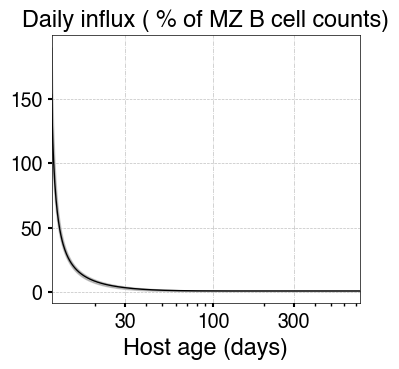

In [ ]:
# Plotting daily influx as a fraction of MZ B cell counts

# Define the birth rate function in terms of t (avoid name clash with variable 'r')
def b_time(rho, M, M_stable, K):
    """Instantaneous logistic birth rate b(M) given parameters."""
    b = rho / (1.0 - (M_stable / K))
    return b * (1.0 - (M / K))

# Define the ODE function with signature (t, y, *args) required by solve_ivp
def ode_function(t, y, phi, rho, delta, M_stable, K):
    M_val = y[0]
    # dMdt = phi * P(t) + b_time(rho, M_val, M_stable, K) * M_val - delta*M_val
    dMdt = phi + b_time(rho, M_val, M_stable, K) * M_val - delta*M_val
    
    return [dMdt]

# Use posterior means (or derive S from posterior samples)
phi = (unified_df.delta - unified_df.rho) * unified_df.M_stable
rho = unified_df.rho
delta = unified_df.delta
M_stable = unified_df.M_stable
K = unified_df.K



M0 = [12058.0]
# use a reasonable time step (very small dt can make solver struggle); 0.1 matches other cells
t_ev = np.arange(11.0, 750.0, 0.1)
sol = np.zeros((len(rho), len(t_ev)))
for i in range(len(rho)):
    # Solve once over the full interval (vectorized call) instead of calling solve_ivp in a loop
    result = solve_ivp(ode_function,
                        [t_ev[0], t_ev[-1]],
                M0,
                t_eval=t_ev,
                args=(phi[i], rho[i], delta[i], M_stable[i], K[i]))
    sol[i, :] = result.y[0]

# Extract solution and compute influx(t)/M(t)
influx_rate = np.zeros((len(t_ev), len(rho)))
for i in range(len(rho)):
    M_t = sol[i, :]
    influx_rate[:, i] = (phi[i] / M_t)*100 # Daily influx as a fraction of MZ B cell counts
    
    
    
# Calculate statistics
influx_rate_median = np.mean(influx_rate, axis=1)
influx_rate_lower = np.quantile(influx_rate, 0.025, axis=1)
influx_rate_upper = np.quantile(influx_rate, 0.975, axis=1)
fig, axes = plt.subplots(1, 1, figsize=(4, 4))
axes.plot(t_ev, influx_rate_median, color='black', linewidth=1)
axes.fill_between(t_ev, influx_rate_lower, influx_rate_upper, alpha=0.2, color='black')
# axes.set_ylim(0, 2)
# plt.yticks([0, 0.5, 1.0, 1.5, 2.0], [0, 0.5, 1.0, 1.5, 2.0])
axes.set_xlim(11, 740)
plt.xscale('log')
# plt.yscale('log')
plt.xticks([ 30, 100, 300], [ 30, 100, 300])
# axes.set_ylabel('Daily influx / MZ B cell count')   
plt.title('Daily influx ( % of MZ B cell counts)')            
axes.set_xlabel('Host age (days)')
ax = plt.gca()
# Axis border width
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.tick_params(axis="both", labelsize=14)
# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1.5)
ax.tick_params(axis="both", which="minor", length=2, width=1)
axes.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
axes.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
plt.tight_layout()          
plt.savefig('figures/Ontogeny_Daily_Influx_Fraction.pdf', dpi=300)
plt.show()  
